# Caricamento dataset e analisi esplorativa

In [1]:
import pandas as pd

df = pd.read_csv("obesity.csv")

df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [2]:
# Abbiamo etichetta categorica e anche varie features categoriche, controlliamo se mancano dati

print(df.isna().mean() * 100) # nessun dato mancancante, non e' necessario effetuare imputazione

X = df.drop(columns=["NObeyesdad", "Height", 'Weight'])
y = df["NObeyesdad"]

Gender                            0.0
Age                               0.0
Height                            0.0
Weight                            0.0
family_history_with_overweight    0.0
FAVC                              0.0
FCVC                              0.0
NCP                               0.0
CAEC                              0.0
SMOKE                             0.0
CH2O                              0.0
SCC                               0.0
FAF                               0.0
TUE                               0.0
CALC                              0.0
MTRANS                            0.0
NObeyesdad                        0.0
dtype: float64


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)


X_train,X_test,y_train,y_test = train_test_split(X,y_encoded,stratify=y_encoded, random_state=42, test_size=0.15)

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_features = X_train.select_dtypes(include=["number"]).columns
cat_features = X_train.select_dtypes(include=["bool", "string", "object"]).columns

num_pipeline = Pipeline(steps=[
    ("scaler", StandardScaler())
])
cat_pipeline = Pipeline(steps=[
    ("encoder", OneHotEncoder(sparse_output=False, handle_unknown="ignore")),    
])

preprocessor = ColumnTransformer(transformers=[
    ("num", num_pipeline, num_features),
    ("cat", cat_pipeline, cat_features)
])

preprocessor.set_output(transform="pandas")

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)



In [4]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

print(pd.Series(y_encoded).nunique()) # Riduciamo a 6 componenti

lda = LinearDiscriminantAnalysis(n_components=6)
lda.set_output(transform="pandas")

X_train_final = lda.fit_transform(X_train_processed, y_train)
X_test_final = lda.transform(X_test_processed)


X_train_final.head()

7


,lineardiscriminantanalysis0,lineardiscriminantanalysis1,lineardiscriminantanalysis2,lineardiscriminantanalysis3,lineardiscriminantanalysis4,lineardiscriminantanalysis5
1994,-1.759820,1.618697,0.113933,-0.030606,-0.106041,-0.159806
17,2.135896,-0.206614,2.165050,-0.598240,-0.718384,-0.952843
206,2.619496,-0.078775,-0.955919,-0.744595,-0.500364,-1.836518
1944,-1.506729,1.426129,-0.340150,0.325120,0.026926,-0.137547
1198,-1.161730,0.284089,-0.870580,0.626337,-0.235445,-0.481803


In [5]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier

grid_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy'] 
}

cv = StratifiedKFold(n_splits=5, random_state=42, shuffle=True)
rfc = RandomForestClassifier(random_state=42)
grid = GridSearchCV(estimator=rfc, param_grid=grid_params, scoring='accuracy', cv=cv)

grid.fit(X_train_final, y_train)




,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [None, 5, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [50, 100, ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [6]:
best_model = grid.best_estimator_
best_score = grid.best_score_
best_params = grid.best_params_

test_acc = best_model.score(X_test_final, y_test)

print(f"Miglior modello : {best_model}")
print(f"Migliori iperparametri: {best_params}")
print(f"Miglior punteggio: {best_score}")

print(f"Test accuracy : {test_acc}")

Miglior modello : RandomForestClassifier(criterion='entropy', min_samples_split=5,
                       n_estimators=200, random_state=42)
Migliori iperparametri: {'criterion': 'entropy', 'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
Miglior punteggio: 0.7519662003392416
Test accuracy : 0.7287066246056783


# rete neurale

In [7]:
import torch
import numpy as np
import torchnn as tnn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split

X_train_nn, X_val_nn, y_train_nn, y_val_nn = train_test_split(X_train_final, y_train, stratify=y_train, random_state=42, test_size=0.15)
# tensore = (batch_size, canali, lunghezza)

class Data(Dataset):
    def __init__(self,X,y):
        self.X = torch.tensor(np.array(X), dtype=torch.float32).unsqueeze(1)
        self.y = torch.tensor(np.array(y), dtype=torch.long)
    def __getitem__(self, index):
        return self.X[index], self.y[index]
    def __len__(self):
        return len(self.X)

train_data = Data(X_train_nn, y_train_nn)
val_data = Data(X_val_nn, y_val_nn)
test_data = Data(X_test_final, y_test)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader = DataLoader(val_data, batch_size=64, shuffle=False)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

from torch import nn
from torch.functional import F  

class Net(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv1d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(32,64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(32)
        self.bn2 = nn.BatchNorm1d(64)
        self.pool = nn.AdaptiveAvgPool1d(1) # si andra' a moltiplicare con i canali in uscita
        self.fc1 = nn.Linear(64,128)
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(128,7)
    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool(x) # x.shape al momento (64,64,1)
        x = torch.flatten(x, start_dim=1)  # x.shape dopo flatten(64,64)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x
    print("modello caricato!")




modello caricato!


# Addestramento modello


Epoch    1: 100%|██████████| 24/24 [00:00<00:00, 28.42it/s]


Train loss: 1.8156
Validation loss: 1.6745
Test loss: 1.7185 Accuracy:   0.44
Metrics:



Epoch    2: 100%|██████████| 24/24 [00:00<00:00, 215.34it/s]


Train loss: 1.5207
Validation loss: 1.3175
Test loss: 1.4008 Accuracy:   0.52
Metrics:



Epoch    3: 100%|██████████| 24/24 [00:00<00:00, 208.80it/s]


Train loss: 1.3156
Validation loss: 1.1801
Test loss: 1.2619 Accuracy:   0.58
Metrics:



Epoch    4: 100%|██████████| 24/24 [00:00<00:00, 247.59it/s]


Train loss: 1.2010
Validation loss: 1.1287
Test loss: 1.1958 Accuracy:   0.60
Metrics:



Epoch    5: 100%|██████████| 24/24 [00:00<00:00, 237.22it/s]


Train loss: 1.1363
Validation loss: 1.0934
Test loss: 1.1604 Accuracy:   0.62
Metrics:



Epoch    6: 100%|██████████| 24/24 [00:00<00:00, 229.47it/s]


Train loss: 1.1016
Validation loss: 1.0490
Test loss: 1.1370 Accuracy:   0.62
Metrics:



Epoch    7: 100%|██████████| 24/24 [00:00<00:00, 307.79it/s]


Train loss: 1.0705
Validation loss: 1.0469
Test loss: 1.1049 Accuracy:   0.62
Metrics:



Epoch    8: 100%|██████████| 24/24 [00:00<00:00, 277.05it/s]


Train loss: 1.0469
Validation loss: 1.0454
Test loss: 1.0808 Accuracy:   0.61
Metrics:



Epoch    9: 100%|██████████| 24/24 [00:00<00:00, 287.84it/s]


Train loss: 1.0277
Validation loss: 1.0097
Test loss: 1.0826 Accuracy:   0.62
Metrics:



Epoch   10: 100%|██████████| 24/24 [00:00<00:00, 272.30it/s]


Train loss: 1.0044
Validation loss: 1.0186
Test loss: 1.0874 Accuracy:   0.62
Metrics:



Epoch   11: 100%|██████████| 24/24 [00:00<00:00, 275.30it/s]


Train loss: 1.0042
Validation loss: 1.0160
Test loss: 1.1103 Accuracy:   0.63
Metrics:



Epoch   12: 100%|██████████| 24/24 [00:00<00:00, 283.25it/s]


Train loss: 0.9746
Validation loss: 0.9971
Test loss: 1.0617 Accuracy:   0.66
Metrics:



Epoch   13: 100%|██████████| 24/24 [00:00<00:00, 281.73it/s]


Train loss: 0.9731
Validation loss: 1.0122
Test loss: 1.0506 Accuracy:   0.61
Metrics:



Epoch   14: 100%|██████████| 24/24 [00:00<00:00, 280.35it/s]


Train loss: 0.9625
Validation loss: 1.0028
Test loss: 1.0442 Accuracy:   0.61
Metrics:



Epoch   15: 100%|██████████| 24/24 [00:00<00:00, 276.28it/s]


Train loss: 0.9424
Validation loss: 0.9727
Test loss: 1.0151 Accuracy:   0.66
Metrics:



Epoch   16: 100%|██████████| 24/24 [00:00<00:00, 311.99it/s]


Train loss: 0.9411
Validation loss: 0.9852
Test loss: 1.0310 Accuracy:   0.62
Metrics:



Epoch   17: 100%|██████████| 24/24 [00:00<00:00, 314.51it/s]


Train loss: 0.9413
Validation loss: 0.9680
Test loss: 1.0177 Accuracy:   0.64
Metrics:



Epoch   18: 100%|██████████| 24/24 [00:00<00:00, 296.99it/s]


Train loss: 0.9239
Validation loss: 1.0222
Test loss: 1.0608 Accuracy:   0.63
Metrics:



Epoch   19: 100%|██████████| 24/24 [00:00<00:00, 277.91it/s]


Train loss: 0.9175
Validation loss: 0.9832
Test loss: 1.0290 Accuracy:   0.65
Metrics:



Epoch   20: 100%|██████████| 24/24 [00:00<00:00, 259.04it/s]


Train loss: 0.9042
Validation loss: 0.9519
Test loss: 1.0025 Accuracy:   0.66
Metrics:



Epoch   21: 100%|██████████| 24/24 [00:00<00:00, 280.84it/s]


Train loss: 0.8976
Validation loss: 0.9946
Test loss: 1.0149 Accuracy:   0.63
Metrics:



Epoch   22: 100%|██████████| 24/24 [00:00<00:00, 248.18it/s]


Train loss: 0.8960
Validation loss: 0.9509
Test loss: 1.0011 Accuracy:   0.63
Metrics:



Epoch   23: 100%|██████████| 24/24 [00:00<00:00, 272.25it/s]


Train loss: 0.8839
Validation loss: 0.9470
Test loss: 1.0130 Accuracy:   0.65
Metrics:



Epoch   24: 100%|██████████| 24/24 [00:00<00:00, 250.39it/s]


Train loss: 0.8689
Validation loss: 0.9757
Test loss: 0.9868 Accuracy:   0.63
Metrics:



Epoch   25: 100%|██████████| 24/24 [00:00<00:00, 270.90it/s]


Train loss: 0.8543
Validation loss: 0.9607
Test loss: 0.9940 Accuracy:   0.67
Metrics:



Epoch   26: 100%|██████████| 24/24 [00:00<00:00, 242.79it/s]


Train loss: 0.8435
Validation loss: 0.9450
Test loss: 0.9766 Accuracy:   0.68
Metrics:



Epoch   27: 100%|██████████| 24/24 [00:00<00:00, 178.52it/s]


Train loss: 0.8622
Validation loss: 0.9641
Test loss: 0.9949 Accuracy:   0.63
Metrics:



Epoch   28: 100%|██████████| 24/24 [00:00<00:00, 250.14it/s]


Train loss: 0.8528
Validation loss: 0.9622
Test loss: 0.9881 Accuracy:   0.68
Metrics:



Epoch   29: 100%|██████████| 24/24 [00:00<00:00, 288.18it/s]


Train loss: 0.8488
Validation loss: 0.9628
Test loss: 0.9909 Accuracy:   0.65
Metrics:



Epoch   30: 100%|██████████| 24/24 [00:00<00:00, 326.72it/s]


Train loss: 0.8431
Validation loss: 0.9315
Test loss: 0.9647 Accuracy:   0.69
Metrics:



Epoch   31: 100%|██████████| 24/24 [00:00<00:00, 195.42it/s]


Train loss: 0.8289
Validation loss: 0.9642
Test loss: 0.9685 Accuracy:   0.65
Metrics:



Epoch   32: 100%|██████████| 24/24 [00:00<00:00, 222.07it/s]


Train loss: 0.8332
Validation loss: 0.9756
Test loss: 0.9827 Accuracy:   0.62
Metrics:



Epoch   33: 100%|██████████| 24/24 [00:00<00:00, 200.64it/s]


Train loss: 0.8537
Validation loss: 0.9750
Test loss: 0.9871 Accuracy:   0.63
Metrics:



Epoch   34: 100%|██████████| 24/24 [00:00<00:00, 191.07it/s]


Train loss: 0.8098
Validation loss: 0.9293
Test loss: 0.9314 Accuracy:   0.67
Metrics:



Epoch   35: 100%|██████████| 24/24 [00:00<00:00, 243.30it/s]


Train loss: 0.8063
Validation loss: 0.9178
Test loss: 0.9475 Accuracy:   0.68
Metrics:



Epoch   36: 100%|██████████| 24/24 [00:00<00:00, 206.88it/s]


Train loss: 0.8050
Validation loss: 1.0233
Test loss: 1.0179 Accuracy:   0.66
Metrics:



Epoch   37: 100%|██████████| 24/24 [00:00<00:00, 180.86it/s]


Train loss: 0.8093
Validation loss: 1.0244
Test loss: 1.0952 Accuracy:   0.60
Metrics:



Epoch   38: 100%|██████████| 24/24 [00:00<00:00, 242.65it/s]


Train loss: 0.8080
Validation loss: 0.9325
Test loss: 0.9802 Accuracy:   0.66
Metrics:



Epoch   39: 100%|██████████| 24/24 [00:00<00:00, 224.58it/s]


Train loss: 0.7811
Validation loss: 0.9549
Test loss: 0.9453 Accuracy:   0.69
Metrics:



Epoch   40: 100%|██████████| 24/24 [00:00<00:00, 200.86it/s]


Train loss: 0.7780
Validation loss: 0.9299
Test loss: 0.9541 Accuracy:   0.69
Metrics:



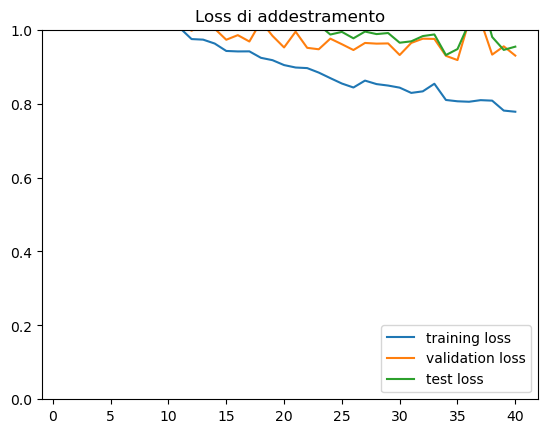

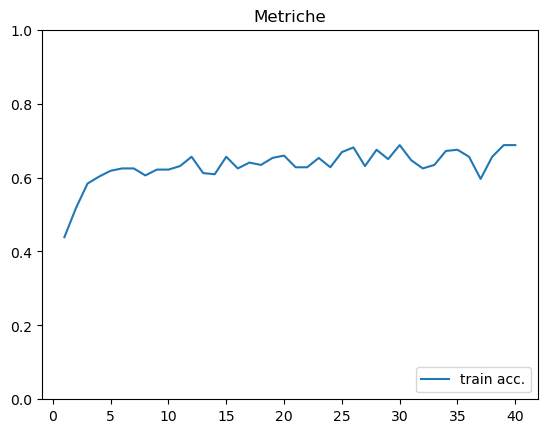

In [8]:
import torch.optim as optim

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = Net().to(device)

optimizer = optim.Adam(model.parameters(), lr=0.001)
early_stopping = tnn.EarlyStopping(patience=5, min_delta=0.001)
loss_fn = nn.CrossEntropyLoss()

train_loss, validation_loss, test_loss, accuracy, test_metrics = tnn.train_test(
    model=model,
    optimizer=optimizer,
    train_dataloader=train_loader,
    test_dataloader=test_loader,
    val_dataloader=val_loader,
    epochs=50,
    train_loss_fn=loss_fn,
    test_loss_fn=loss_fn,
    early_stopping=early_stopping,
    device=device,
    average='micro',
    metrics=[]
)

tnn.displayLosses(train_loss, test_loss, validation_loss)
tnn.displayMetrics(accuracy, test_metrics)

tnn.save_model(
    model,
    optimizer,
    len(train_loss), 
    train_loss,
    validation_loss, 
    test_loss, 
    accuracy, 
    test_metrics, 
    "best_conv1d.pt")


# Metriche e Matrice di confusione


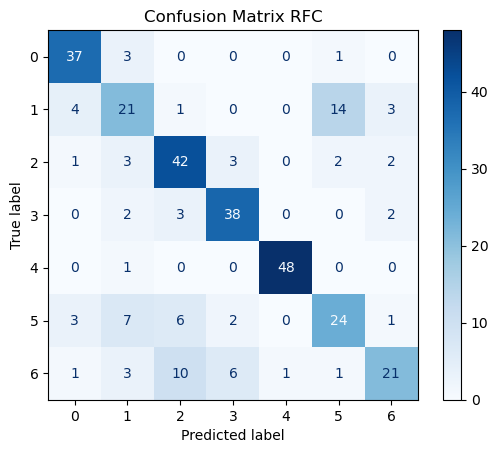

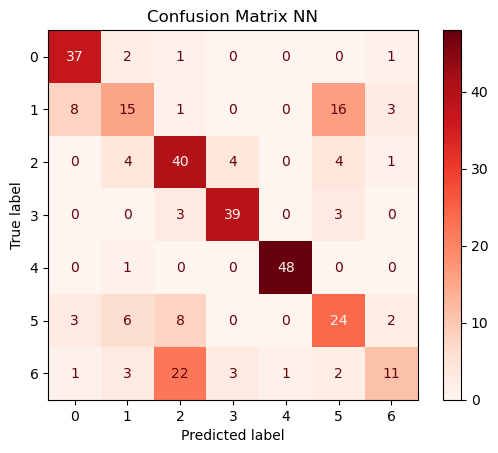

c:\Users\1234r\anaconda3\envs\bigdata\Lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
c:\Users\1234r\anaconda3\envs\bigdata\Lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


Auc Macro RFC: 0.9330831239465353
Auc Micro RFC: 0.9466359502035049
Auc Macro NN: 0.9098768913166468
Auc Micro NN: 0.9280767049129756


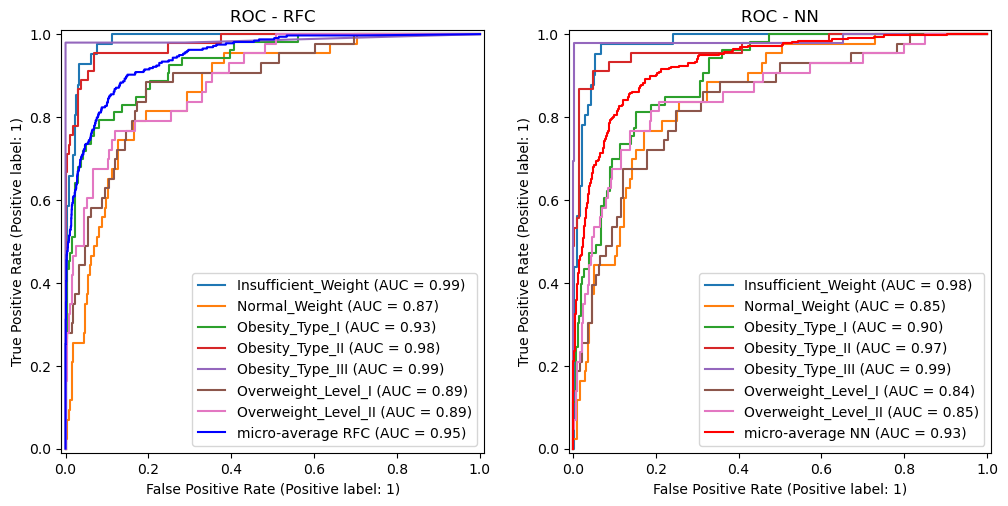

In [9]:
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay, confusion_matrix, roc_auc_score
from sklearn.preprocessing import LabelBinarizer
import matplotlib.pyplot as plt

def valuate(model, test_loader, device, loss_fn):
    model.eval()
    nn_true, nn_pred, nn_prob, losses = [],[],[], []

    # Disabilitiamo il calcolo del gradiente per migliore efficienza

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            logits = model(X_batch)
            losses.append(loss_fn(logits, y_batch).item())

            """dim=1 perche' senza dim softmax tratta l'intero tensore (batch, 7) come se fosse un unico vettore 
            appiattito, e restituisce un solo indice scalare.
            
            Perché ti serve lo stesso criterio in entrambi i casi, ed è il punto da fissarti in testa: 
            ogni volta che un'operazione di PyTorch collassa un tensore lungo un asse (somma, media, max, argmax, softmax...), 
            e tu hai più dimensioni, devi sempre dire esplicitamente su quale asse operare, 
            altrimenti PyTorch assume "su tutto", che quasi mai è quello che vuoi quando lavori con batch di dati. 
            Con logits/prob shape (batch, n_classi), dim=1 è quasi sempre la risposta giusta in questo tipo 
            di codice, perché è l'asse delle classi, non del batch.

            """

            # I tensori che stiamo manipolando hanno forma (batch, 7) e la funzione deve agire sulla dimensione 1 
            # ovvero le classi di classificazione che vogliamo
            
            prob = torch.softmax(logits, dim=1)
            pred = torch.argmax(prob, dim=1)

            nn_true.extend(y_batch.cpu().numpy())
            nn_pred.extend(pred.cpu().numpy())
            nn_prob.extend(prob.cpu().numpy())

    nn_true = np.array(nn_true)
    nn_pred = np.array(nn_pred)
    nn_prob = np.array(nn_prob)

    return nn_true, nn_pred, nn_prob, losses

best_model, optimizer, checkpoint = tnn.load_model("best_conv1d.pt", model, optimizer, device)


nn_true, nn_pred, nn_prob, losses = valuate(best_model, test_loader, device, loss_fn)

# plotting matrici di confusioni 

# Matrice di confusione RandomForestClassifier

rfc_pred = grid.predict(X_test_final)


cm1 = ConfusionMatrixDisplay.from_predictions(y_test, rfc_pred, cmap='Blues',)
plt.title("Confusion Matrix RFC")
plt.show()

cm2 = ConfusionMatrixDisplay.from_predictions(nn_true, nn_pred, cmap='Reds',)
plt.title("Confusion Matrix NN")
plt.show()

rfc_prob = grid.predict_proba(X_test_final)

# Dobbiamo calcolare Auc e Roc, ma bisogna tenere conto che questa e' classificazione MULTICLASSE e non binaria
# Dobbiamo fare un LabelBinarizer fissando y_test_gb

n_classes=7
lb = LabelBinarizer().fit(y_train)
y_test_rfc_bin = lb.transform(y_test)
nn_true_bin = lb.transform(nn_true) 

class_names = le.classes_

fig,ax = plt.subplots(1,2, figsize=(12,7))

for i,classes in enumerate(class_names):
    # Per ciascuna classe stampiamo AuC
    RocCurveDisplay.from_predictions(y_test_rfc_bin[:,i], rfc_prob[:,i], name=classes, ax=ax[0])
    ax[0].set_title("ROC - RFC")
    
   

for i,classes in enumerate(class_names):
    # Per ciascuna classe stampiamo AuC
    RocCurveDisplay.from_predictions(nn_true_bin[:,i], nn_prob[:,i], name=classes, ax=ax[1])
    ax[1].set_title("ROC - NN")

# Curve Micro Average Aggregate
RocCurveDisplay.from_predictions(y_test_rfc_bin.ravel(),rfc_prob.ravel(),name="micro-average RFC", color="blue", ax=ax[0])
RocCurveDisplay.from_predictions(nn_true_bin.ravel(),nn_prob.ravel(),name="micro-average NN", color="red", ax=ax[1])




# valori AUC (Micro e Macro)

auc_rfc_micro = roc_auc_score(y_test_rfc_bin, rfc_prob, average="micro", multi_class='ovr')   
auc_rfc_macro = roc_auc_score(y_test_rfc_bin, rfc_prob, average="macro", multi_class='ovr')

auc_nn_micro = roc_auc_score(nn_true_bin, nn_prob, average="micro", multi_class='ovr')   
auc_nn_macro = roc_auc_score(nn_true_bin, nn_prob, average="macro", multi_class='ovr')

print(f"Auc Macro RFC: {auc_rfc_macro}")
print(f"Auc Micro RFC: {auc_rfc_micro}")


print(f"Auc Macro NN: {auc_nn_macro}")
print(f"Auc Micro NN: {auc_nn_micro}")
